
# BCG unsuitable-segment estimation using wavelets

This notebook implements the core segmentation idea from the paper:

**“An Improved Estimation of Unsuitable Segments of Ballistocardiography Records Using Wavelet Transforms.”**


## OBS

This notebook is a practical re-implementation based on the paper description. A few details are not fully specified in the paper, so the implementation makes reasonable engineering choices:

- the paper states a 1-second moving window
- the paper uses the **Gaus2** mother wavelet at **scale 16**
- the paper defines:
  - `Ws = (W1 + W2)/2`
  - `Thd_max = mean(W1 + W2)`
  - `Thd_min = mean(W1 + W2) * 0.1`
- the paper expands each threshold crossing by **±150 ms**


In [69]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import pywt
from pathlib import Path
import scipy.signal as sg

plt.rcParams["figure.figsize"] = (14, 5)



## 1. Helper functions

This is a list of helper functions. Some of them are probably irrelevant now


In [70]:

def bandpass_filter(x, fs, lowcut, highcut, order=4):
    x = np.asarray(x, dtype=float)
    x = sg.detrend(x)
    sos = sg.butter(order, [lowcut, highcut], btype="bandpass", fs=fs, output="sos")
    return sg.sosfiltfilt(sos, x)


def moving_std(x, window_samples):
    s = pd.Series(np.asarray(x, dtype=float))
    return s.rolling(window=window_samples, center=True, min_periods=1).std(ddof=0).to_numpy()


def moving_var(x, window_samples):
    s = pd.Series(np.asarray(x, dtype=float))
    return s.rolling(window=window_samples, center=True, min_periods=1).var(ddof=0).to_numpy()


def expand_mask(mask, radius_samples):
    mask = np.asarray(mask, dtype=bool)
    kernel = np.ones(2 * radius_samples + 1, dtype=int)
    expanded = np.convolve(mask.astype(int), kernel, mode="same") > 0
    return expanded


def cwt_gaus2_scale16(x):
    coeffs, freqs = pywt.cwt(x, scales=[16], wavelet="gaus2")
    return coeffs[0]


def segmentation_proposed(bcg, fs):
    window_samples = int(fs * 2.0) ##These are mostly guesses since the paper doesn't say what they sbould be, expect fluffyness!
    margin_samples = int(fs * 0.3) ## -||-

    cwt_bcg = cwt_gaus2_scale16(bcg)

    W1 = moving_std(bcg, window_samples)
    W2 = moving_std(cwt_bcg, window_samples)

    Ws = (W1 + W2) / 2.0

    thd_max = np.mean(W1 + W2)
    thd_min = np.mean(W1 + W2) * 0.1

    high_artifact = Ws > thd_max
    low_signal = Ws < thd_min

    high_artifact_expanded = expand_mask(high_artifact, margin_samples)
    low_signal_expanded = expand_mask(low_signal, margin_samples)

    seg = np.ones_like(Ws, dtype=int)
    seg[low_signal_expanded] = 0
    seg[high_artifact_expanded] = 2

    return {
        "cwt_bcg": cwt_bcg,
        "W1": W1,
        "W2": W2,
        "Ws": Ws,
        "thd_max": thd_max,
        "thd_min": thd_min,
        "seg": seg,
        "usable_mask": seg == 1,
        "artifact_mask": seg == 2,
        "low_signal_mask": seg == 0,
    }


def segmentation_variance_baseline(bcg, fs):
    window_samples = int(fs * 0.1)
    margin_samples = int(fs * 0.0150)

    Wvar = moving_var(bcg, window_samples)

    thd_max = np.mean(Wvar)
    thd_min = np.mean(Wvar) * 0.1

    high_artifact = Wvar > thd_max
    low_signal = Wvar < thd_min

    high_artifact_expanded = expand_mask(high_artifact, margin_samples)
    low_signal_expanded = expand_mask(low_signal, margin_samples)

    seg = np.ones_like(Wvar, dtype=int)
    seg[low_signal_expanded] = 0
    seg[high_artifact_expanded] = 2

    return {
        "Wvar": Wvar,
        "thd_max": thd_max,
        "thd_min": thd_min,
        "seg": seg,
        "usable_mask": seg == 1,
        "artifact_mask": seg == 2,
        "low_signal_mask": seg == 0,
    }


def detect_ecg_rpeaks(ecg, fs):
    distance = int(0.6 * fs) #Increase this to increase length of the local area for local maxima & minima
    prominence = np.std(ecg) * 0.7 #Increase this to increase the "prominence" essentially keep only those that are at least x above their local group
    peaks, props = signal.find_peaks(ecg, distance=distance, prominence=prominence)
    return peaks


def coverage_factor_from_ecg(seg_usable_mask, rpeaks):
    if len(rpeaks) == 0:
        return np.nan, 0, 0
    usable_beats = int(np.sum(seg_usable_mask[rpeaks]))
    total_beats = len(rpeaks)
    cf = 100.0 * usable_beats / total_beats
    return cf, usable_beats, total_beats



## 2. Load the data

This loads the data from the csv file 



In [71]:



#BCG_PATH = Path("Sitting_april13_Christian.csv")
#BCG_PATH = Path("Emil_Sitting_No_Sock_17_April.csv")
#BCG_PATH = Path("recording_20260420_184643_sitting.csv")
#ECG_PATH = Path("Emil_No_Sock_17_AprilECG.csv")
BCG_PATH = Path("Data\Mustafa_Måling_23_April\BCG_Mustafa_Standing_a0_capture_20260423_124500.csv")
ECG_PATH = Path("Data\Mustafa_Måling_23_April\Mustafa_Måling_Standing_ECG.csv")
#BCG_PATH = Path("Data\Mustafa_Måling_23_April\Musti_Trimmed\BCG_Mustafa_Sitting_trimmed.csv")
#ECG_PATH = Path("Data\Mustafa_Måling_23_April\Musti_Trimmed\ECG_Mustafa_Sitting_trimmed.csv")

fileName = BCG_PATH
#TIME_COLUMN = "unix_time_s"
#BCG_COLUMN = "voltage_a0"
#AUX_COLUMN = "voltage_a3"
ECG_COLUMN = None
TIME_COLUMN = "unix_time_s"
BCG_COLUMN = "voltage_a0"


df = pd.read_csv(BCG_PATH)
bcg_raw = df[BCG_COLUMN].to_numpy(dtype=float)
#aux_raw = df[AUX_COLUMN].to_numpy(dtype=float) if AUX_COLUMN in df.columns else None ##REALLY USELESS CONSIDER DELETING
ecg_raw = None

time_unix = df[TIME_COLUMN].to_numpy(dtype=float)
time = time_unix - time_unix[0]

dt = np.diff(time)
dt = dt[np.isfinite(dt) & (dt > 0)]
if len(dt) == 0:
    FS = 200.0
    time = np.arange(len(bcg_raw)) / FS
else:
    FS = float(np.round(1.0 / np.median(dt)))

print(f"Loaded {BCG_PATH.name} with {len(bcg_raw)} samples.")
print(f"Using FS = {FS:.2f} Hz")
print(f"BCG column: {BCG_COLUMN}")
#print(f"Aux column: {AUX_COLUMN if aux_raw is not None else 'None'}")


Loaded BCG_Mustafa_Standing_a0_capture_20260423_124500.csv with 59997 samples.
Using FS = 200.00 Hz
BCG column: voltage_a0


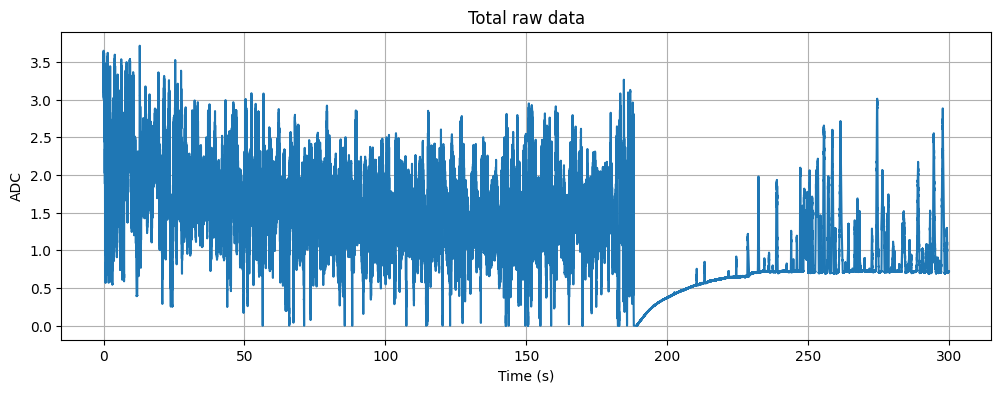

In [72]:
bcg_df = pd.read_csv(BCG_PATH)



time_Bcg = bcg_df["unix_time_s"].to_numpy(dtype=float)
Bcg_raw = bcg_df["voltage_a0"].to_numpy(dtype=float)
duration = time_Bcg[-1] - time_Bcg[0]
FS_Bcg = len(Bcg_raw) / duration

Raw_data = BCG_COLUMN
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(Bcg_raw)) / FS_Bcg, Bcg_raw)
plt.title("Total raw data")
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.grid(True)
plt.show()

Loaded ECG with 25554 samples
Duration = 300.07 s
Estimated FS = 85.16 Hz


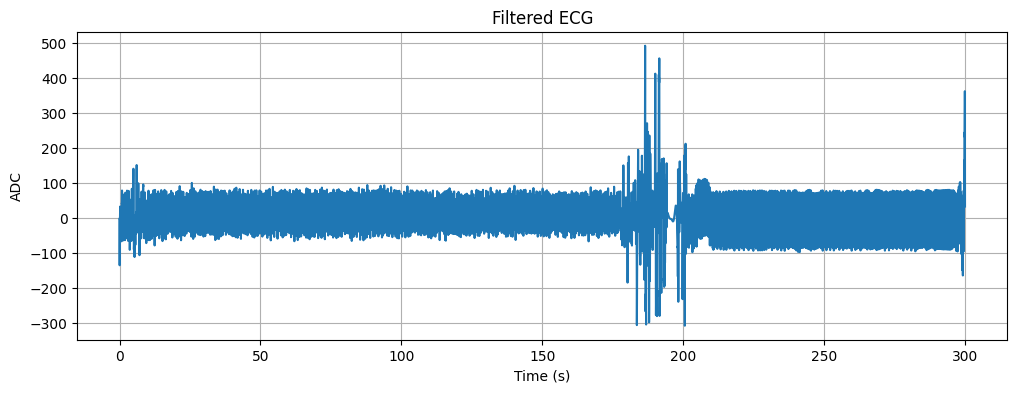

In [73]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import *
from scipy.fft import fft, fftfreq

ecg_df = pd.read_csv(ECG_PATH)

time_ecg = ecg_df["relative_time_s"].to_numpy(dtype=float)
ecg_raw = ecg_df["adc"].to_numpy(dtype=float)

duration = time_ecg[-1] - time_ecg[0]
FS_ecg = len(ecg_raw) / duration

ecg = bandpass_filter(ecg_raw, FS_ecg, 0.5, 10.0, order=4)
ecg = ecg - np.mean(ecg)

print(f"Loaded ECG with {len(ecg_raw)} samples")
print(f"Duration = {duration:.2f} s")
print(f"Estimated FS = {FS_ecg:.2f} Hz")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(ecg)) / FS_ecg, ecg)
plt.title("Filtered ECG")
plt.xlabel("Time (s)")
plt.ylabel("ADC")
plt.grid(True)
plt.show()

In [74]:
print(time_ecg[:10])
print(np.diff(time_ecg[:10]))
print(len(ecg_raw), time_ecg[-1] - time_ecg[0])

[1.0e-06 0.0e+00 1.0e-02 1.9e-02 2.8e-02 3.7e-02 4.7e-02 5.6e-02 6.5e-02
 7.5e-02]
[-1.e-06  1.e-02  9.e-03  9.e-03  9.e-03  1.e-02  9.e-03  9.e-03  1.e-02]
25554 300.07099900000003


In [75]:

bcg = bandpass_filter(bcg_raw, FS, 1, 10.0, order=4)

res_prop = segmentation_proposed(bcg, FS)
res_var = segmentation_variance_baseline(bcg, FS)
thd_max = res_prop["thd_max"]
thd_min = res_prop["thd_min"]


print("Proposed method thresholds:")
print("  thd_max =", res_prop["thd_max"])
print("  thd_min =", res_prop["thd_min"])

print("\nVariance baseline thresholds:")
print("  thd_max =", res_var["thd_max"])
print("  thd_min =", res_var["thd_min"])


Proposed method thresholds:
  thd_max = 0.82623477781989
  thd_min = 0.082623477781989

Variance baseline thresholds:
  thd_max = 0.010058251007174859
  thd_min = 0.001005825100717486


### ECG With Welch

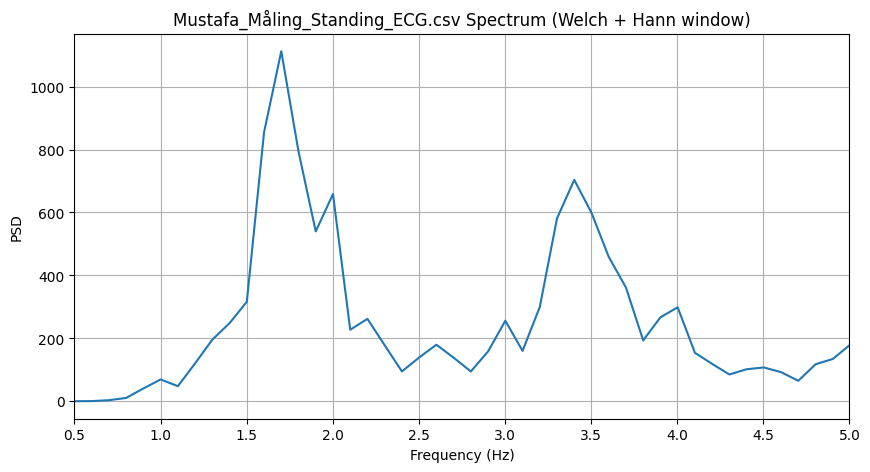

Estimated heart rate from ECG: 102.1 bpm


In [76]:
signal = detrend(ecg_raw.astype(float))
signal = signal - np.mean(signal)
signal = bandpass_filter(signal, FS_ecg, 1, 10.0, order=4)

f, Pxx = welch(
    signal,
    fs=FS_ecg,
    window="hann",
    nperseg=int(FS_ecg * 10),
    noverlap=int(FS_ecg * 5)
)

plt.figure(figsize=(10, 5))
plt.plot(f, Pxx)
plt.xlim(0.5, 5.0)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title(f"{ECG_PATH.name} Spectrum (Welch + Hann window)")
plt.grid(True)
plt.show()

band = (f >= 0.7) & (f <= 3.0)
peak_freq = f[band][np.argmax(Pxx[band])]
print(f"Estimated heart rate from ECG: {peak_freq * 60:.1f} bpm")

### BCG With Welch

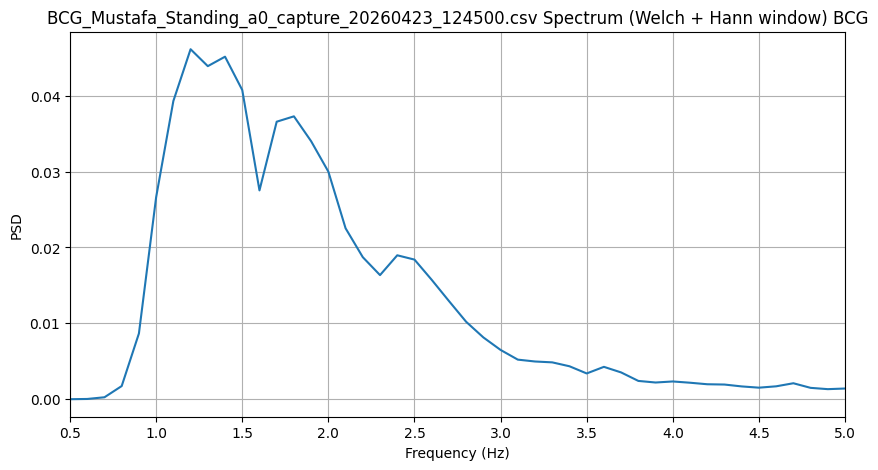

Estimated heart rate: 72.0 bpm
[78. 84. 72.]


In [77]:
from scipy.signal import welch


signal = bcg_raw.copy()
signal = signal - np.mean(signal)
signal2 = bandpass_filter(signal, FS, 1, 10.0, order=4)
bcg_clean = bcg.copy()
bcg_clean[~res_prop["usable_mask"]] = 0.0  # zero out bad segments


f, Pxx = welch(signal2, fs=FS, window='hann', nperseg=int(FS*10), noverlap=int(FS*5))
f2, Pxx2 = welch(bcg_clean, fs=FS, window="hann",
               nperseg=int(FS * 10), noverlap=int(FS * 5))
plt.figure(figsize=(10, 5))
plt.plot(f, Pxx)
plt.xlim(0.5, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title(f"{BCG_PATH.name} Spectrum (Welch + Hann window) BCG")
plt.grid(True)
plt.show()


band = (f >= 0.8) & (f <= 3)
peak_freq = f[band][np.argmax(Pxx[band])]
print(f"Estimated heart rate: {peak_freq * 60:.1f} bpm")
indices = np.argsort(Pxx[band])[-3:]


print(f[band][indices] * 60)

### ECG With FFT (fourier)

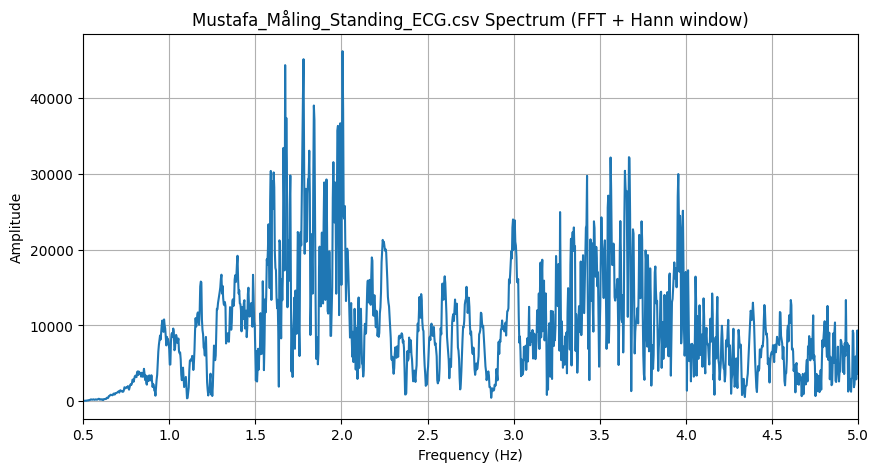

Estimated heart rate: 120.4 bpm
[100.37624462 106.77473034 120.37151248]


In [78]:
from scipy.signal import welch


signal = detrend(ecg_raw.astype(float))
signal = signal - np.mean(signal)
signal2 = bandpass_filter(signal, FS_ecg, 1, 10.0, order=4)
f = np.fft.rfftfreq(len(signal2), 1/FS_ecg); 
A = np.abs(np.fft.rfft(signal2 * np.hanning(len(signal2))))
plt.figure(figsize=(10, 5))
plt.plot(f, A)
plt.xlim(0.5, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title(f"{ECG_PATH.name} Spectrum (FFT + Hann window)")
plt.grid(True)
plt.show()

band = (f >= 0.8) & (f <= 3)
peak_freq = f[band][np.argmax(A[band])]
print(f"Estimated heart rate: {peak_freq * 60:.1f} bpm")
indices = np.argsort(A[band])[-3:]
print(f[band][indices] * 60)

### BCG With FFT (fourier)

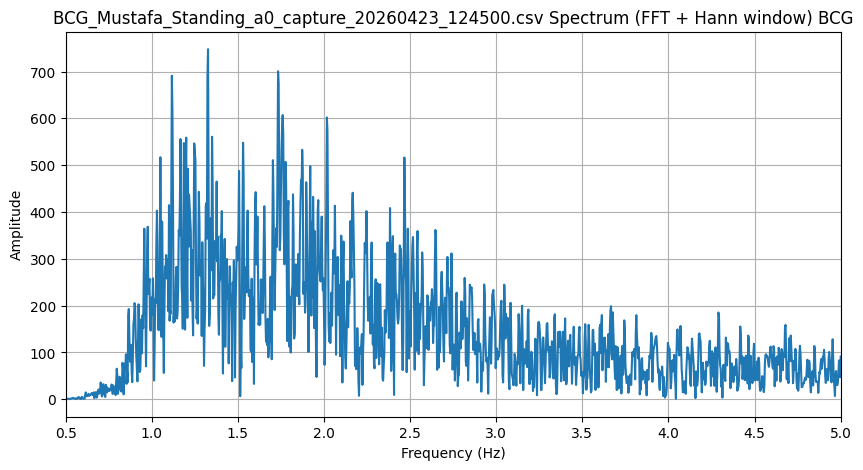

Estimated heart rate: 79.6 bpm
[ 67.00335017 104.00520026  79.6039802 ]


In [79]:
from scipy.signal import welch


signal = bcg_raw.copy()
signal = signal - np.mean(signal)
signal2 = bandpass_filter(signal, FS, 1, 10.0, order=4)

f = np.fft.rfftfreq(len(signal2), 1/FS);  A = np.abs(np.fft.rfft(signal2 * np.hanning(len(signal2))))


plt.figure(figsize=(10, 5))
plt.plot(f, A)
plt.xlim(0.5, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title(f"{BCG_PATH.name} Spectrum (FFT + Hann window) BCG" )
plt.grid(True)
plt.show()

band = (f >= 0.8) & (f <= 3)
peak_freq = f[band][np.argmax(A[band])]
print(f"Estimated heart rate: {peak_freq * 60:.1f} bpm")
indices = np.argsort(A[band])[-3:]
print(f[band][indices] * 60)


## 4. Preprocess signals

According to the paper:
- BCG bandwidth: `0.3–24 Hz`
- ECG bandwidth: `0.5–40 Hz`


Preprocessing complete.
Raw range: 0.0000 to 3.7154
Filtered range: -1.7496 to 1.5473


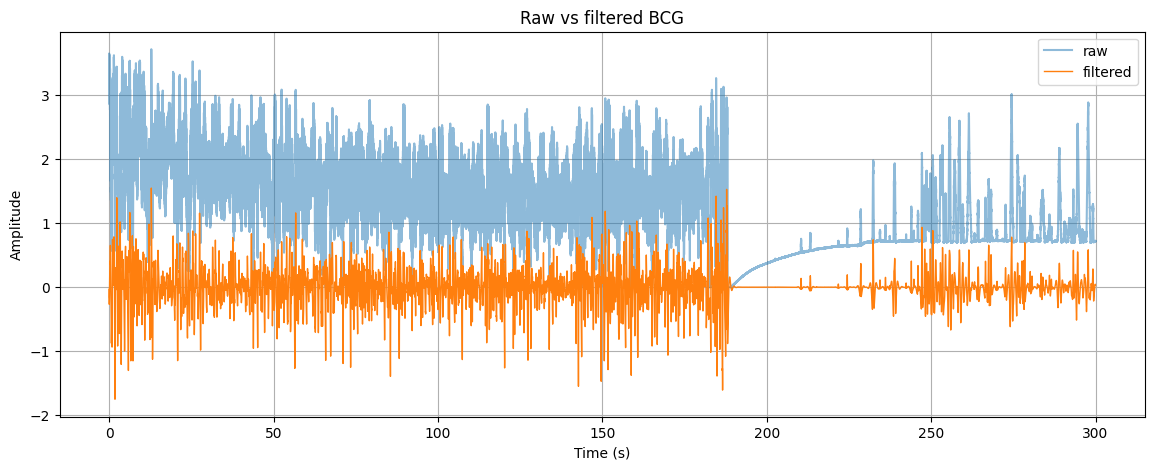

In [80]:
from scipy import signal

bcg = bandpass_filter(bcg_raw, FS, 0.8, 10.0, order=4)

if ecg_raw is not None:
    ecg = bandpass_filter(ecg_raw, FS, 0.5, 40.0, order=4)
else:
    ecg = None

print("Preprocessing complete.")
print(f"Raw range: {bcg_raw.min():.4f} to {bcg_raw.max():.4f}")
print(f"Filtered range: {bcg.min():.4f} to {bcg.max():.4f}")

plt.figure(figsize=(14, 5))
plt.plot(time, bcg_raw, label="raw", alpha=0.5)
plt.plot(time, bcg, label="filtered", linewidth=1)
plt.title("Raw vs filtered BCG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


### Thresholds according to the paper

In [81]:

res_prop = segmentation_proposed(bcg, FS)
res_var = segmentation_variance_baseline(bcg, FS)
thd_max = res_prop["thd_max"]
thd_min = res_prop["thd_min"]


print("Proposed method thresholds:")
print("  thd_max =", res_prop["thd_max"])
print("  thd_min =", res_prop["thd_min"])

print("\nVariance baseline thresholds:")
print("  thd_max =", res_var["thd_max"])
print("  thd_min =", res_var["thd_min"])


Proposed method thresholds:
  thd_max = 0.8661242022512238
  thd_min = 0.08661242022512239

Variance baseline thresholds:
  thd_max = 0.010672642800195037
  thd_min = 0.0010672642800195037


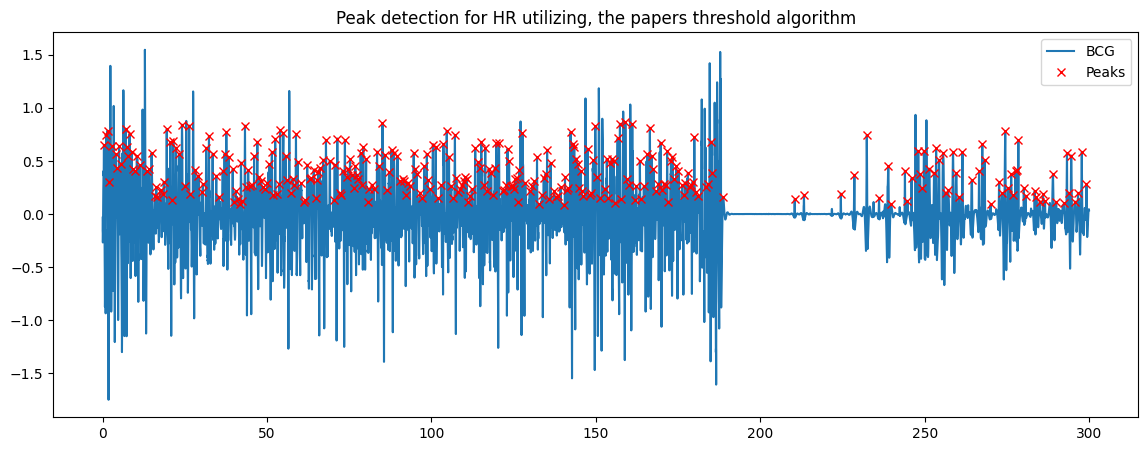

Heart Rate: 67.1 bpm
Number of peaks: 335


In [82]:
from scipy import signal

# --- PEAK DETECTION ---
peaks, _ = signal.find_peaks(
    bcg,
    distance=0.3* FS,
    prominence=np.std(bcg) * 0.6
)
peak_values = bcg[peaks]
#print(peak_values[:10])
mask = (peak_values > thd_min) & (peak_values < thd_max)
filtered_peaks = peaks[mask]

### THIS IS WITHOUT THRESHOLD
# Plot to verify
""" plt.figure(figsize=(14,5))
plt.plot(time, bcg, label="BCG")
plt.plot(time[peaks], bcg[peaks], "rx", label="Peaks")
plt.legend()
plt.title("Peak detection for HR")
plt.show()



# --- HEART RATE ---
if len(peaks) > 2:
    rr = np.diff(time[peaks])
    hr = 60 / np.mean(rr)
    print(f"Heart rate: {hr:.1f} bpm")
else:
    print("Not enough peaks to estimate HR")

print("Number of peaks:", len(peaks)) """


### THIS IS WITH THRESHOLD
# Real plot (with threshold)
plt.figure(figsize=(14,5))
plt.plot(time, bcg, label="BCG")
plt.plot(time[filtered_peaks], bcg[filtered_peaks], "rx", label="Peaks")
plt.legend()
plt.title("Peak detection for HR utilizing, the papers threshold algorithm")
plt.show()

## TRUE HEART RATE 
if len(mask) > 2: 
    rr = np.diff(time[filtered_peaks])
    hr = 60/np.mean(rr) 
    print(f"Heart Rate: {hr:.1f} bpm")
    print("Number of peaks:", len(filtered_peaks))
else: 
    print("Not enough peaks to estimate HR")





## 6. Plot full-record overview


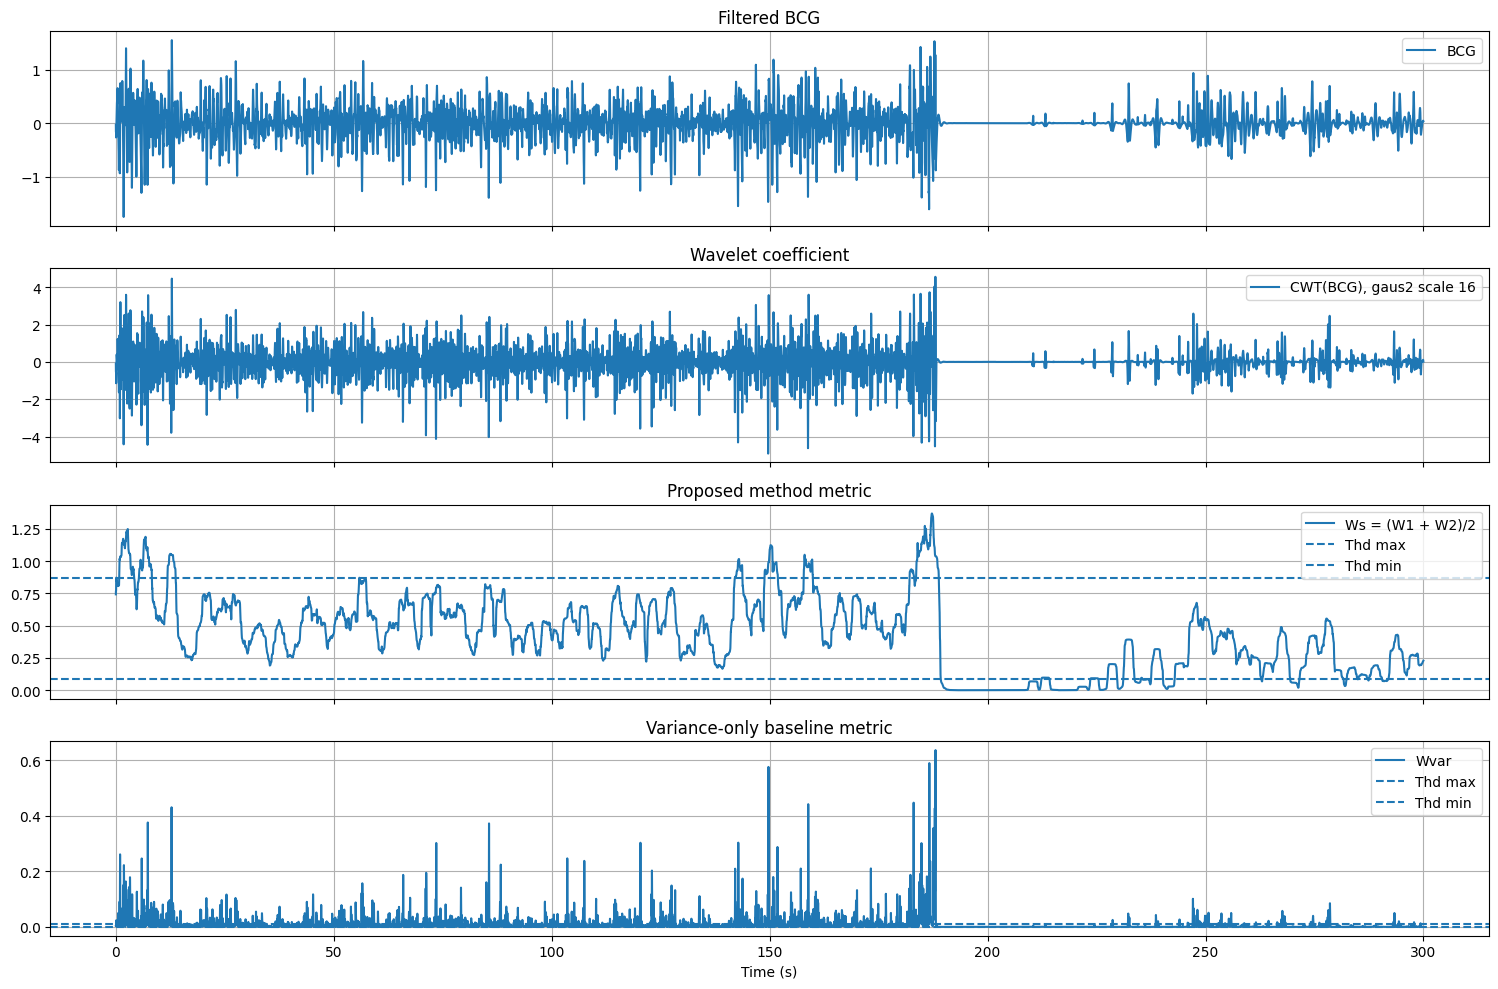

In [83]:

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

axes[0].plot(time, bcg, label="BCG")
axes[0].set_title("Filtered BCG")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time, res_prop["cwt_bcg"], label="CWT(BCG), gaus2 scale 16")
axes[1].set_title("Wavelet coefficient")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time, res_prop["Ws"], label="Ws = (W1 + W2)/2")
axes[2].axhline(res_prop["thd_max"], linestyle="--", label="Thd max")
axes[2].axhline(res_prop["thd_min"], linestyle="--", label="Thd min")
axes[2].set_title("Proposed method metric")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(time, res_var["Wvar"], label="Wvar")
axes[3].axhline(res_var["thd_max"], linestyle="--", label="Thd max")
axes[3].axhline(res_var["thd_min"], linestyle="--", label="Thd min")
axes[3].set_title("Variance-only baseline metric")
axes[3].legend()
axes[3].grid(True)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()



## 7. Plot segmentation labels

Label meaning:
- `0` = weak / absent signal
- `1` = usable
- `2` = artifact / large variation


ValueError: x and y must have same first dimension, but have shapes (59997,) and (25554,)

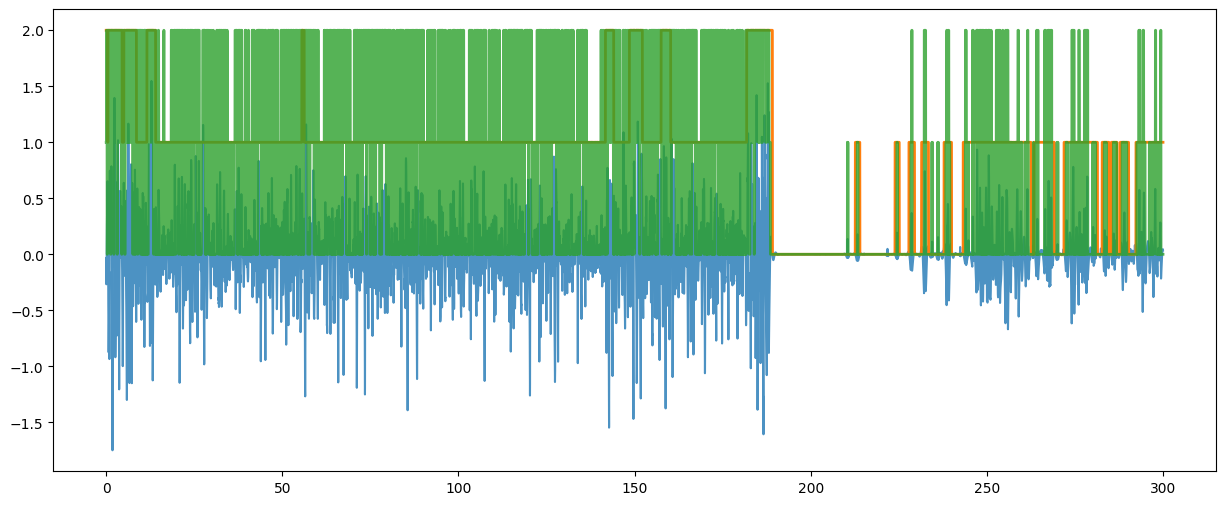

In [84]:

plt.figure(figsize=(15, 6))
plt.plot(time, bcg, label="BCG", alpha=0.8)
plt.plot(time, res_prop["seg"], label="Seg proposed", linewidth=2)
plt.plot(time, res_var["seg"], label="Seg variance", linewidth=2, alpha=0.8)
if ecg is not None:
    plt.plot(time, ecg, label="ECG", alpha=0.7)
plt.title("Signal and segmentation comparison")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)
plt.show()



## 8. Zoom into a time interval

Change `t0` and `t1` to inspect examples like the figures in the paper.


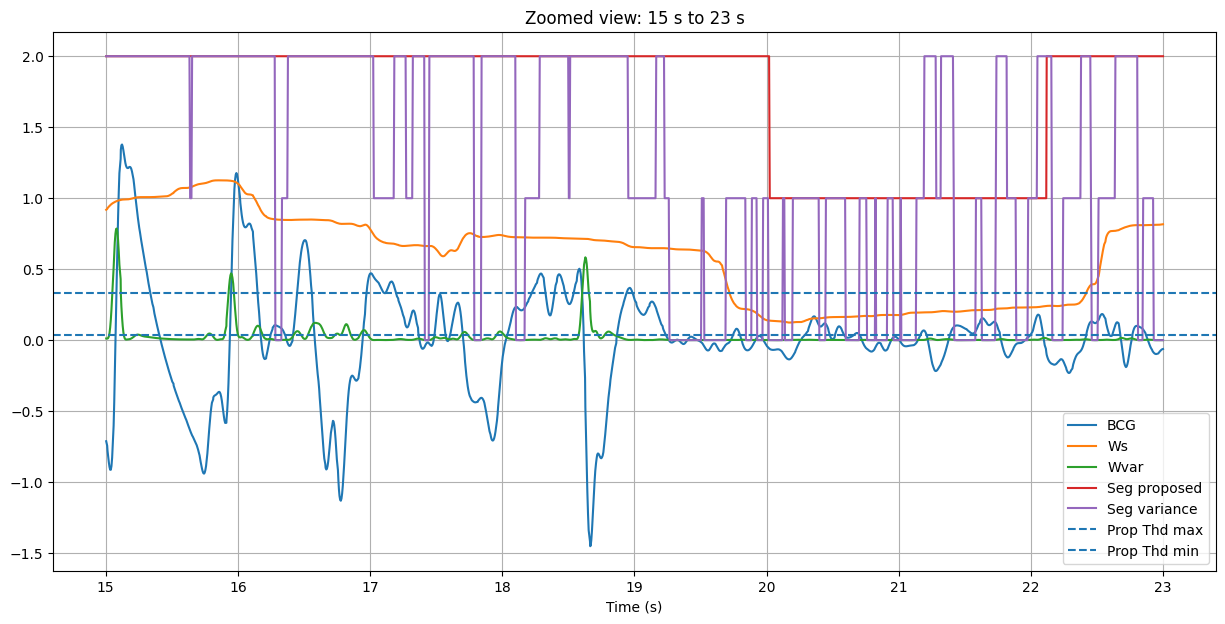

In [ ]:

t0, t1 = 15, 23
idx = (time >= t0) & (time <= t1)

plt.figure(figsize=(15, 7))
plt.plot(time[idx], bcg[idx], label="BCG")
plt.plot(time[idx], res_prop["Ws"][idx], label="Ws")
plt.plot(time[idx], res_var["Wvar"][idx], label="Wvar")
plt.plot(time[idx], res_prop["seg"][idx], label="Seg proposed")
plt.plot(time[idx], res_var["seg"][idx], label="Seg variance")
plt.axhline(res_prop["thd_max"], linestyle="--", label="Prop Thd max")
plt.axhline(res_prop["thd_min"], linestyle="--", label="Prop Thd min")
plt.title(f"Zoomed view: {t0} s to {t1} s")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)
plt.show()



## 9. Coverage factor (CF) using ECG beat counts

The paper defines coverage factor as:

`CF = suitable heartbeats / total heartbeats × 100`

This cell uses ECG R-peaks as the reference heartbeat count.


In [ ]:

if ecg is not None:
    rpeaks = detect_ecg_rpeaks(ecg, FS)

    cf_prop, usable_prop, total_beats = coverage_factor_from_ecg(res_prop["usable_mask"], rpeaks)
    cf_var, usable_var, _ = coverage_factor_from_ecg(res_var["usable_mask"], rpeaks)

    print(f"Total beats: {total_beats}")
    print(f"Proposed method: CF = {cf_prop:.2f}% ({usable_prop}/{total_beats})")
    print(f"Variance baseline: CF = {cf_var:.2f}% ({usable_var}/{total_beats})")
    print(f"Difference in beats kept: {usable_prop - usable_var}")
else:
    print("No ECG available, so CF cannot be computed in this cell.")


No ECG available, so CF cannot be computed in this cell.
